In [1]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn tensorflow

In [37]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [38]:
df = pd.read_csv("/content/Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [39]:
def clean_html(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['review'] = df['review'].apply(clean_html)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)


In [40]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(preprocess_text)
df.head()


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...
1,A wonderful little production. The filming tec...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [41]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0, 'neutral': 2})
df = df[df['label'] != 2]  # Optional: remove 'neutral' if not used
df.head()


,review,sentiment,clean_review,label
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...,1
1,A wonderful little production. The filming tec...,positive,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,1


In [42]:
X = df['clean_review']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


In [45]:
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [46]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [47]:
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.86      0.86      0.86       760
           1       0.86      0.86      0.86       740

    accuracy                           0.86      1500
   macro avg       0.86      0.86      0.86      1500
weighted avg       0.86      0.86      0.86      1500



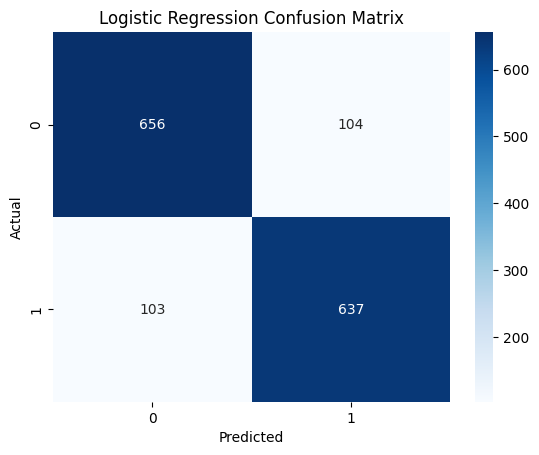

In [48]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [62]:
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Save tokenizer after fitting
with open('/content/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)


In [50]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=Adam(1e-4), metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = model.fit(X_train_pad, y_train, validation_split=0.2, epochs=5, batch_size=64)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 482ms/step - accuracy: 0.5047 - loss: 0.6929 - val_accuracy: 0.5900 - val_loss: 0.6922
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 481ms/step - accuracy: 0.5815 - loss: 0.6912 - val_accuracy: 0.5914 - val_loss: 0.6907
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 460ms/step - accuracy: 0.6671 - loss: 0.6879 - val_accuracy: 0.6386 - val_loss: 0.6823
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 456ms/step - accuracy: 0.6782 - loss: 0.6519 - val_accuracy: 0.7700 - val_loss: 0.5500
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 511ms/step - accuracy: 0.7867 - loss: 0.5148 - val_accuracy: 0.7586 - val_loss: 0.5857


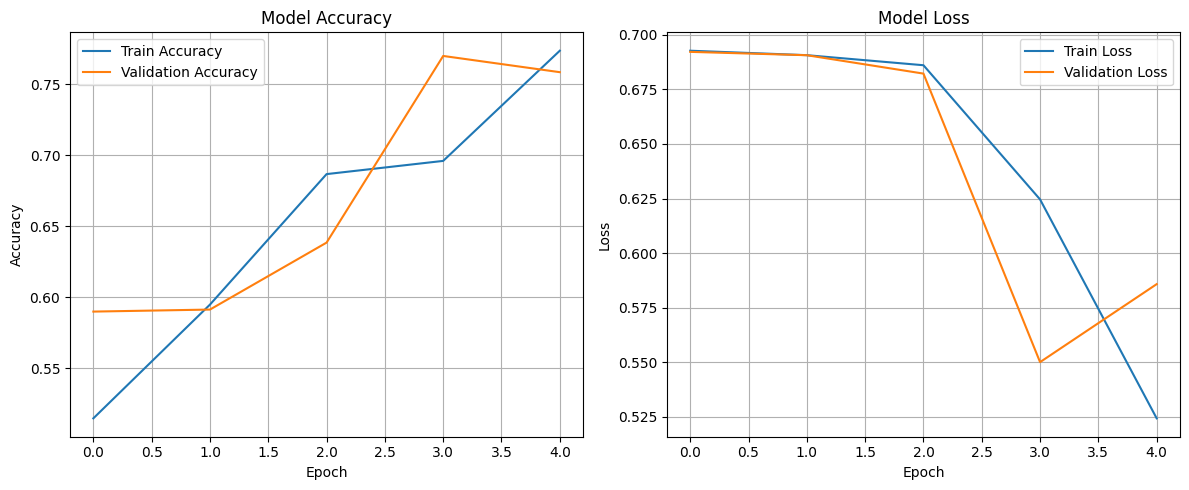

In [52]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [53]:
y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype('int32')
print(classification_report(y_test, y_pred_lstm))


47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       760
           1       0.75      0.85      0.80       740

    accuracy                           0.79      1500
   macro avg       0.79      0.79      0.79      1500
weighted avg       0.79      0.79      0.79      1500



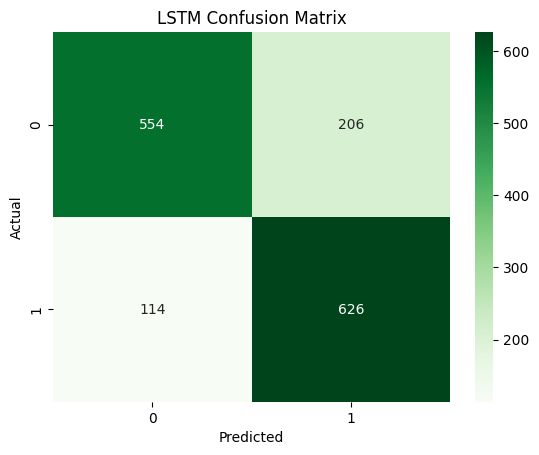

In [54]:
sns.heatmap(confusion_matrix(y_test, y_pred_lstm), annot=True, fmt='d', cmap='Greens')
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [55]:
import joblib

# Assuming your logistic regression model is named `lr_model`
joblib.dump(lr_model, 'logistic_regression_model.pkl')
model.save('lstm_model.h5')


In [80]:
from tensorflow.keras.models import load_model

model_new = load_model('/content/lstm_model.h5')

In [82]:
model_new.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,715 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [76]:
import re
import joblib
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

# Load models and vectorizer
lr_model = joblib.load('/content/logistic_regression_model.pkl')
tfidf_vectorizer = joblib.load('/content/tfidf_vectorizer.pkl')
model = load_model('/content/lstm_model.h5')

# Example: load tokenizer from json or pickle
import pickle
with open('/content/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

max_len = 200  # Use your max_len consistent with training

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text, tokenizer, max_len):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')
    return padded_seq

# Input interface
comment = input("Enter your comment for sentiment prediction: ")

# Logistic Regression prediction
cleaned_comment = clean_text(comment)
comment_vector = tfidf_vectorizer.transform([cleaned_comment])
lr_pred = lr_model.predict(comment_vector)[0]
lr_sentiment = 'positive' if lr_pred == 1 else 'negative'

# LSTM prediction
lstm_input = preprocess_text(comment, tokenizer, max_len)
lstm_prob = model.predict(lstm_input)[0][0]
lstm_sentiment = 'positive' if lstm_prob > 0.5 else 'negative'

print(f"Logistic Regression Prediction: {lr_sentiment}")
print(f"LSTM Prediction: {lstm_sentiment}")


Enter your comment for sentiment prediction: I'll give this movie two stars because it teems with beautiful photography. Otherwise, it teems mainly with clichÃ©s and stereotypes: mountain people are either dumb white trash of the fanatically religious or ragged racist kind, or wise white Indians. Indians are magical people who move around without a sound, can disappear in the blink of an eye, talk to animals, and read minds over large distances. And so on and so forth.<br /><br />Throughout the movie I kept wondering what the point of the film was (other than showing me pretty pictures of mountains, log cabins, woods, an assortment of animals, free-spirited mountain-dwellers and freaky people in church).<br /><br />The plot touched a whole range of issues but explored none of them in depth. This was neither a story about growing up during the depression, nor about about being an orphan, nor about a struggle for identity. It tried to be all of those things and more, which made it superf